In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install krippendorff

In [ ]:
!pip install irrCAC

In [ ]:
import itertools
import krippendorff

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from irrCAC.raw import CAC
from collections import Counter
from statsmodels.stats.inter_rater import fleiss_kappa

df = pd.read_csv('CAMINHO DO ARQUIVO')

cols_base = [
    "Resposta 1",
    "Resposta 2",
    "Resposta 3",
    "Resposta 4",
    "Resposta 5"
]

def get_pattern(row):
    return tuple(sorted(Counter(row[cols_base].tolist()).values()))

patterns = df.apply(get_pattern, axis=1)

mask_remove = patterns.isin([
    (1, 2, 2),
    (1, 1, 3)
])

df_filtrado = df[~mask_remove].copy()

print("Linhas após filtro:", len(df_filtrado))

configs = {
    "5 colunas": [
        "Resposta 1",
        "Resposta 2",
        "Resposta 3",
        "Resposta 4",
        "Resposta 5"
    ],

    "Sem Resposta 5": [
        "Resposta 1",
        "Resposta 2",
        "Resposta 3",
        "Resposta 4"
    ],

    "Sem Resposta 4 e 5": [
        "Resposta 1",
        "Resposta 2",
        "Resposta 3"
    ]
}

# Fleiss Kappa

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

categorias = ["Positivo", "Neutro", "Negativo"]

def calcular_kappa(df_local, cols):
    matriz = []

    for _, row in df_local.iterrows():
        respostas = row[cols].tolist()
        contagens = [respostas.count(cat) for cat in categorias]
        matriz.append(contagens)

    matriz_df = pd.DataFrame(matriz, columns=categorias)

    return fleiss_kappa(matriz_df)

print("DATASET COMPLETO")

for nome, cols in configs.items():
    kappa = calcular_kappa(df, cols)
    print(f"{nome}: {kappa:.6f}")

print("\nDATASET FILTRADO")

for nome, cols in configs.items():
    kappa = calcular_kappa(df_filtrado, cols)
    print(f"{nome}: {kappa:.6f}")

# Krippendorff

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

def preparar(df_local, cols):

    data = df_local[cols].copy()

    mapping = {
        "Positivo": 1,
        "Neutro": 0,
        "Negativo": -1
    }

    data = data.replace(mapping)
    data = data.apply(pd.to_numeric, errors="coerce")

    return data

def calcular_alpha(df_local, cols):

    data = preparar(df_local, cols)

    return krippendorff.alpha(
        reliability_data=data.T.values,
        level_of_measurement="nominal"
    )

print("DATASET COMPLETO")

for nome, cols in configs.items():
    alpha = calcular_alpha(df, cols)
    print(f"{nome}: {alpha:.6f}")

print("\nDATASET FILTRADO")

for nome, cols in configs.items():
    alpha = calcular_alpha(df_filtrado, cols)
    print(f"{nome}: {alpha:.6f}")

# Gwet´s AC1

Base total

In [ ]:
dados = df[
    [
        "Resposta 1",
        "Resposta 2",
        "Resposta 3",
        "Resposta 4",
        "Resposta 5"
    ]
].copy()

dados = dados.apply(
    lambda x: x.astype(str).str.strip().str.lower()
)

cac = CAC(
    ratings=dados,
    weights="identity"
)

resultado = cac.gwet()

print(resultado)

Situações de empate

In [ ]:
df_empates = df[df["Desempate 1"].notna()].copy()

dados = df_empates[
    [
        "Resposta 1",
        "Resposta 2",
        "Resposta 3",
        "Resposta 4",
        "Resposta 5",
        "Desempate 1"
    ]
].copy()

print(len(dados))

dados = dados.apply(
    lambda x: x.astype(str).str.strip().str.lower()
)

cac = CAC(
    ratings=dados,
    weights="identity"
)

resultado = cac.gwet()

print(resultado)

# Resultado da classificação

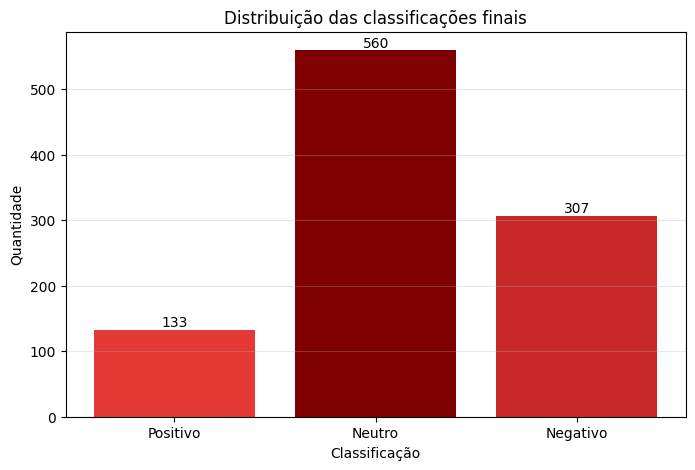

In [ ]:
contagem = (
    df["Final"]
    .astype(str)
    .str.strip()
    .value_counts()
)

ordem = ["Positivo", "Neutro", "Negativo"]

contagem = contagem.reindex(ordem, fill_value=0)

cores = ["#e53935",  "#7f0000", "#c62828"]

plt.figure(figsize=(8, 5))

barras = plt.bar(
    contagem.index,
    contagem.values,
    color=cores
)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.title("Distribuição das classificações finais")
plt.xlabel("Classificação")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.3)

plt.show()

# Padrões de concordância

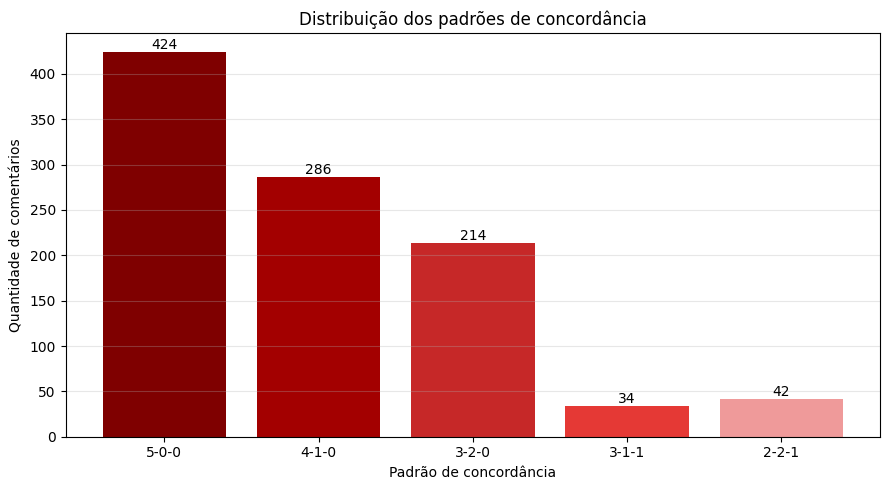

In [ ]:
cols_base = [
    "Resposta 1",
    "Resposta 2",
    "Resposta 3",
    "Resposta 4",
    "Resposta 5"
]

def get_pattern(row):
    counts = Counter(row[cols_base].tolist()).values()

    counts = list(counts)
    counts += [0] * (3 - len(counts))

    return tuple(sorted(counts, reverse=True))

patterns = df.apply(get_pattern, axis=1)

contagem = patterns.value_counts().sort_index(ascending=False)

labels = ["-".join(map(str, p)) for p in contagem.index]

plt.figure(figsize=(9, 5))

cores = [
    "#7f0000",
    "#a30000",
    "#c62828",
    "#e53935",
    "#ef9a9a"
][:len(labels)]

barras = plt.bar(labels, contagem.values, color=cores)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha="center",
        va="bottom"
    )

plt.title("Distribuição dos padrões de concordância")
plt.xlabel("Padrão de concordância")
plt.ylabel("Quantidade de comentários")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Tipos de empate

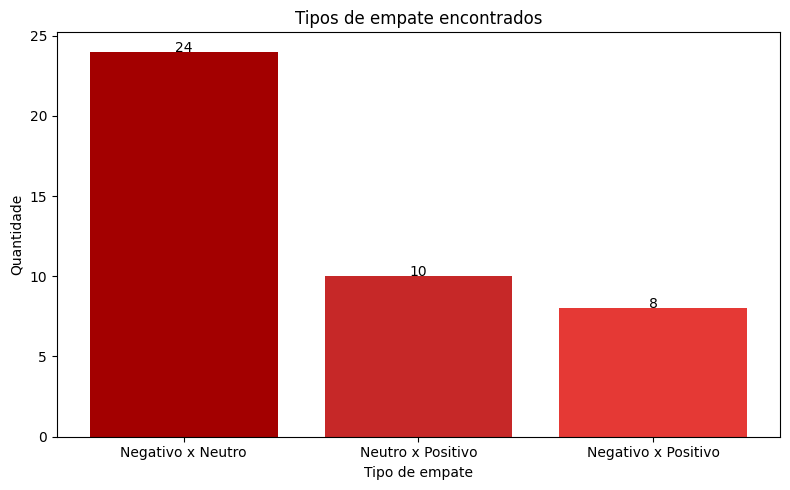

In [ ]:
cols_base = [
    "Resposta 1",
    "Resposta 2",
    "Resposta 3",
    "Resposta 4",
    "Resposta 5"
]

df_empates = df[df["Desempate 1"].notna()].copy()

tipos_empate = []

for _, row in df_empates.iterrows():

    counts = Counter(row[cols_base])

    categorias_empate = sorted(
        [cat for cat, qtd in counts.items() if qtd >= 2]
    )

    tipos_empate.append(" x ".join(categorias_empate))

contagem = pd.Series(tipos_empate).value_counts()

plt.figure(figsize=(8,5))

barras = plt.bar(
    contagem.index,
    contagem.values,
    color = ["#a30000",
              "#c62828",
              "#e53935"]
)

for barra in barras:
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        str(int(barra.get_height())),
        ha="center"
    )

plt.title("Tipos de empate encontrados")
plt.xlabel("Tipo de empate")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

# Desempates

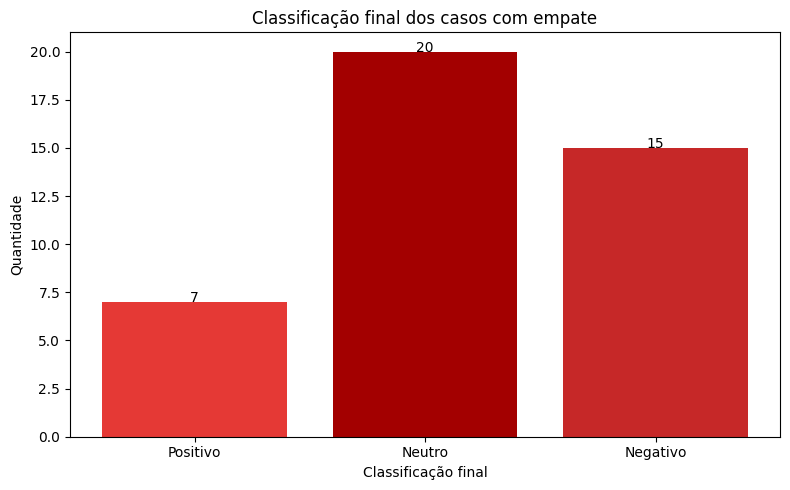

In [ ]:
contagem_final = (
    df_empates["Final"]
    .astype(str)
    .str.strip()
    .value_counts()
)

ordem = ["Positivo", "Neutro", "Negativo"]

contagem_final = contagem_final.reindex(
    ordem,
    fill_value=0
)

plt.figure(figsize=(8,5))

barras = plt.bar(
    contagem_final.index,
    contagem_final.values,
    color = ["#e53935",
              "#a30000",
              "#c62828"]
)

for barra in barras:
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height(),
        str(int(barra.get_height())),
        ha="center"
    )

plt.title("Classificação final dos casos com empate")
plt.xlabel("Classificação final")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()